
*  DSC 530 Data Exploration and Analysis
*  Weeks 7 & 8 Coding Assignment
*  Adam Luna

## Setup

In this section, I import libraries and load the Facebook and earthquake datasets from the Chapter 5 data
directory so they can be reused throughout the assignment.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Locate repository root (notebook is inside the assignments folder)
REPO_ROOT = Path.cwd().parent
CH05_DATA = REPO_ROOT / "ch_05" / "data"

# Define file paths
FB_CSV = CH05_DATA / "fb_stock_prices_2018.csv"
EARTHQUAKES_CSV = CH05_DATA / "earthquakes.csv"

# Load datasets into dataframes
fb = pd.read_csv(FB_CSV)
eq = pd.read_csv(EARTHQUAKES_CSV)

# Convert the date column so pandas recognizes it as time data
fb["date"] = pd.to_datetime(fb["date"])

# Sort chronologically before doing rolling or weekly calculations
fb = fb.sort_values("date")

# Set the date as the index to allow resampling and rolling operations
fb = fb.set_index("date")

# Preview to confirm loading worked
fb.head(), eq.head()

(              open    high       low   close    volume
 date                                                  
 2018-01-02  177.68  181.58  177.5500  181.42  18151903
 2018-01-03  181.88  184.78  181.3300  184.67  16886563
 2018-01-04  184.90  186.21  184.0996  184.33  13880896
 2018-01-05  185.59  186.90  184.9300  186.85  13574535
 2018-01-08  187.20  188.90  186.3300  188.28  17994726,
     mag magType           time                  place  tsunami parsed_place
 0  1.35      ml  1539475168010  9km NE of Aguanga, CA        0   California
 1  1.29      ml  1539475129610  9km NE of Aguanga, CA        0   California
 2  3.42      ml  1539475062610  8km NE of Aguanga, CA        0   California
 3  0.44      ml  1539474978070  9km NE of Aguanga, CA        0   California
 4  2.16      md  1539474716050  10km NW of Avenal, CA        0   California)

# Hands-on data analysis with Pandas

## Chapter 5, Exercise 1

In this section, I calculate and plot the rolling 20-day minimum of Facebook closing prices. Rolling windows smooth daily fluctuations and highlight short-term low price trends.

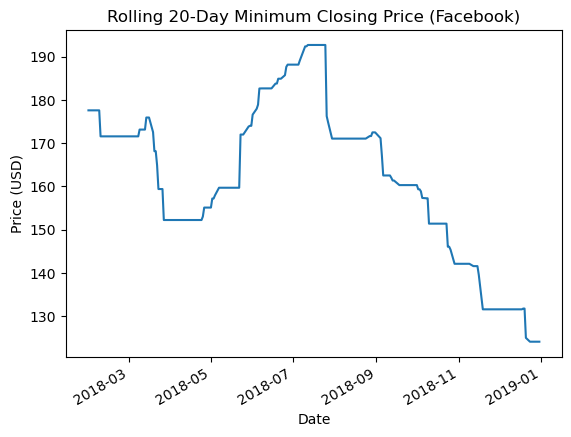

In [2]:
# Calculate rolling 20-day minimum closing price
rolling_min_close = fb["close"].rolling(20).min()

# Plot the rolling minimum values
plt.figure()
rolling_min_close.plot()

# Add labels and title for clarity
plt.title("Rolling 20-Day Minimum Closing Price (Facebook)")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.show()

## Chapter 5, Exercise 2

In this section, I visualize the distribution of daily price change from open to close using a histogram and KDE.

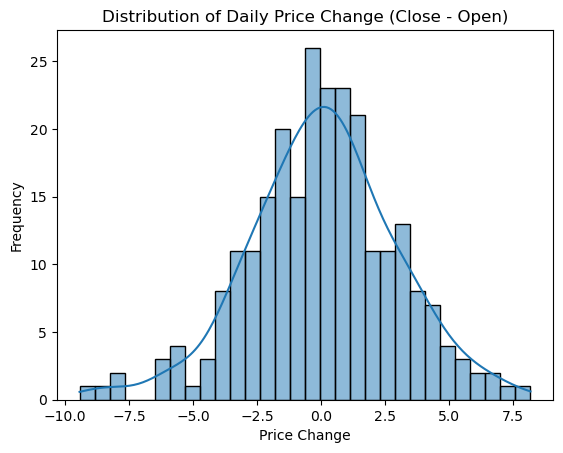

In [3]:
# Compute daily price change (close minus open)
price_change = fb["close"] - fb["open"]

# Remove missing values before plotting
price_change = price_change.dropna()

# Plot histogram with KDE overlay
plt.figure()
sns.histplot(price_change, bins=30, kde=True)

# Label the plot
plt.title("Distribution of Daily Price Change (Close - Open)")
plt.xlabel("Price Change")
plt.ylabel("Frequency")
plt.show()

## Chapter 5, Exercise 3

In this section, I create box plots of earthquake magnitudes for each magnitude type in Indonesia.

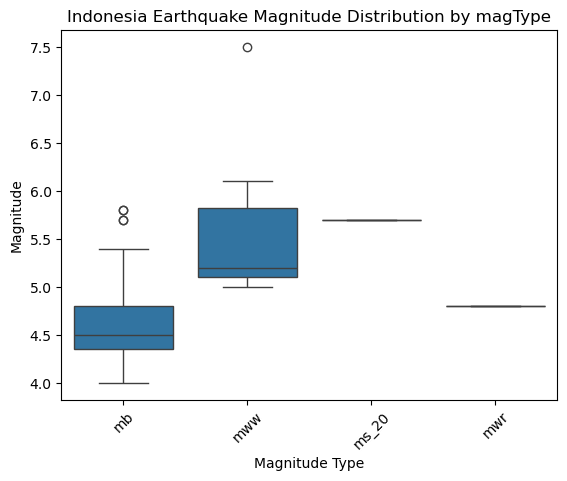

In [4]:
# Filter rows where location mentions Indonesia
indo_eq = eq[eq["place"].str.contains("Indonesia", na=False)]

# Keep rows where magnitude and magnitude type exist
indo_eq = indo_eq.dropna(subset=["mag", "magType"])

# Create box plot grouped by magnitude type
plt.figure()
sns.boxplot(data=indo_eq, x="magType", y="mag")

# Rotate labels for readability
plt.xticks(rotation=45)

plt.title("Indonesia Earthquake Magnitude Distribution by magType")
plt.xlabel("Magnitude Type")
plt.ylabel("Magnitude")
plt.show()

## Chapter 5, Exercise 4

In this section, I plot the weekly difference between maximum high price and minimum low price.

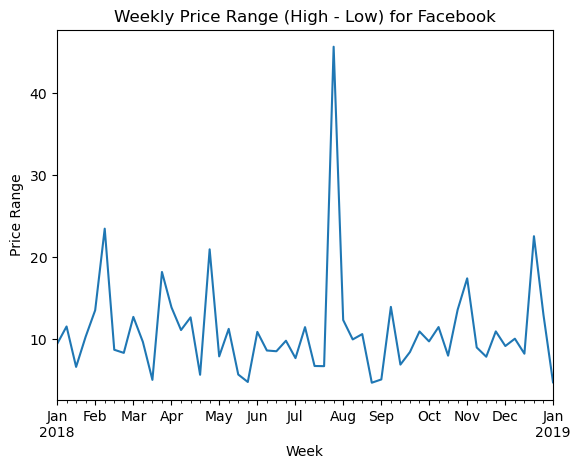

In [5]:
# Resample data weekly and compute max high price
weekly_high = fb["high"].resample("W").max()

# Resample weekly and compute min low price
weekly_low = fb["low"].resample("W").min()

# Compute weekly price range
weekly_difference = weekly_high - weekly_low

# Plot the weekly difference
plt.figure()
weekly_difference.plot()

plt.title("Weekly Price Range (High - Low) for Facebook")
plt.xlabel("Week")
plt.ylabel("Price Range")
plt.show()

## Chapter 6, Exercise 1

In this section, I create a heatmap showing correlation between magnitude and tsunami occurrence for mb earthquakes.

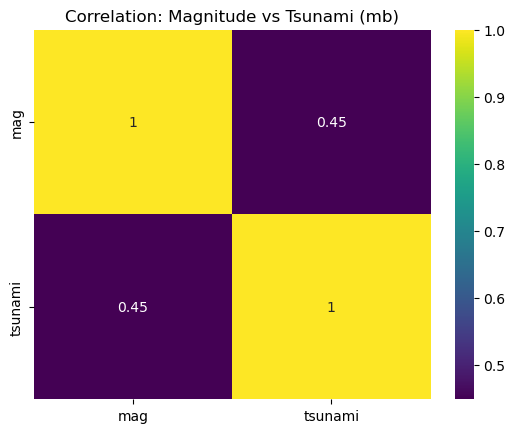

In [6]:
# Select only mb magnitude earthquakes
mb_eq = eq[eq["magType"] == "mb"]

# Keep only relevant columns and remove missing values
mb_eq = mb_eq[["mag", "tsunami"]].dropna()

# Calculate correlation matrix
correlation_matrix = mb_eq.corr()

# Plot heatmap
plt.figure()
sns.heatmap(correlation_matrix, annot=True, cmap="viridis")

plt.title("Correlation: Magnitude vs Tsunami (mb)")
plt.show()

## Chapter 6, Exercise 2

In this section, I create box plots of closing price and trading volume and add Tukey fence reference lines.

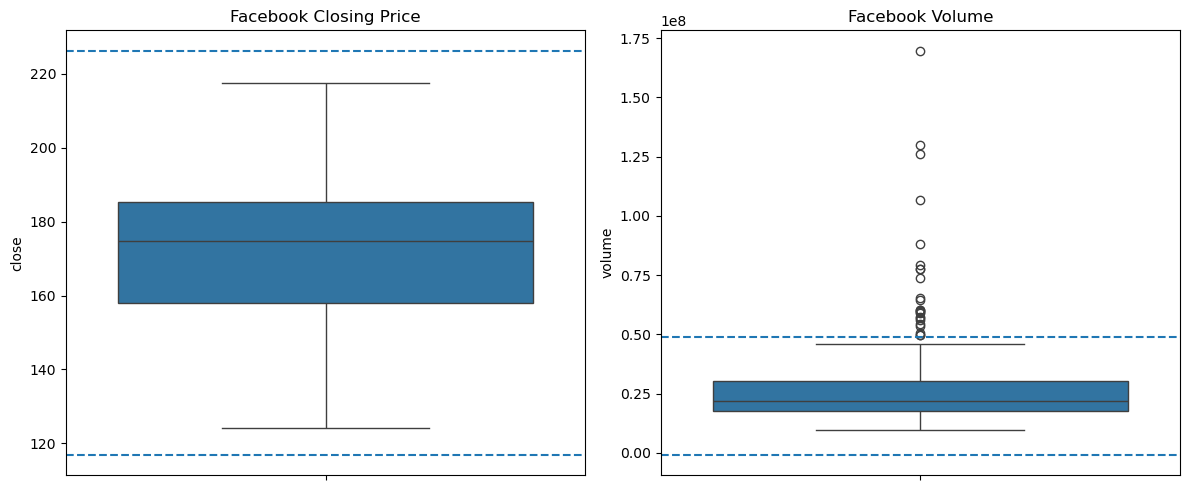

In [7]:
# Calculate quartiles for closing price
q1_close = fb["close"].quantile(0.25)
q3_close = fb["close"].quantile(0.75)
iqr_close = q3_close - q1_close

# Tukey fences
lower_close = q1_close - 1.5 * iqr_close
upper_close = q3_close + 1.5 * iqr_close

# Calculate quartiles for volume
q1_vol = fb["volume"].quantile(0.25)
q3_vol = fb["volume"].quantile(0.75)
iqr_vol = q3_vol - q1_vol

lower_vol = q1_vol - 1.5 * iqr_vol
upper_vol = q3_vol + 1.5 * iqr_vol

# Create subplot figure
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Closing price boxplot
sns.boxplot(y=fb["close"], ax=axes[0])
axes[0].axhline(lower_close, linestyle="--")
axes[0].axhline(upper_close, linestyle="--")
axes[0].set_title("Facebook Closing Price")

# Volume boxplot
sns.boxplot(y=fb["volume"], ax=axes[1])
axes[1].axhline(lower_vol, linestyle="--")
axes[1].axhline(upper_vol, linestyle="--")
axes[1].set_title("Facebook Volume")

plt.tight_layout()
plt.show()